#### Перевод текста c языка зетан на английский (Тренировки по ML 2.0)
**▽◪◎◗▦◫▦◫ ▫▴▨◓◠◓ ▴▫◎◪▱◫ ◚▴ ◞◧▦◞▾▢▱◨▨ ◒◠◓◠◀▪▦◈◠▦ ◫◉◎▴▱◫▵ -> He would need to repeat his vows in the land of the living and drink from the wine of ages**

Импортируем нужные библиотеки

In [1]:
import torch
import torch.nn as nn
from torch.utils import data
import numpy as np
import matplotlib.pyplot as plt
import scipy

from typing import Literal, List, Tuple, Optional

import os
import json
import unicodedata
import math


#### Класс датасета

In [2]:
class ZetanDataset(data.Dataset):
    def __init__(self, path : str, set : Literal['val', 'train', 'test']):
        super().__init__()

        match set:
            case 'val': self.path = os.path.join(path, 'val.jsonl')
            case 'train': self.path = os.path.join(path, 'train.jsonl')
            case 'test': self.path = os.path.join(path, 'test_no_reference.jsonl')
            case _: self.path = os.path.join(path, set)

        self.data = []

        with open(self.path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line: 
                    continue
                row = json.loads(line)
                self.data.append(row)
        
    def __getitem__(self, index):
        return self.data[index]['src'], self.data[index].get('dst', None)
    
    def __len__(self):
        return len(self.data)

In [3]:
zd = ZetanDataset('data', 'test')

In [4]:
PAD, SOS, EOS = 0, 1, 2
BYTE_OFFSET = 3
VOCAB_SIZE = 256 + BYTE_OFFSET
def normalize_text(s: str):
    return ' '.join(unicodedata.normalize('NFC', s).lower().split())

def encode(text : str) -> List[int]:
        text = normalize_text(text)
        b = text.encode()
        ids = [SOS] + [BYTE_OFFSET + x for x in b] + [EOS]
        return ids

In [5]:
src_lengths = []
dst_lengths = []
for ds in (ZetanDataset('data', 'train'), ZetanDataset('data', 'val'), ZetanDataset('data', 'test')):
    for src, dst in ds:
        src_lengths.append(len(encode(src)))
        if dst is not None:
            dst_lengths.append(len(encode(dst)))

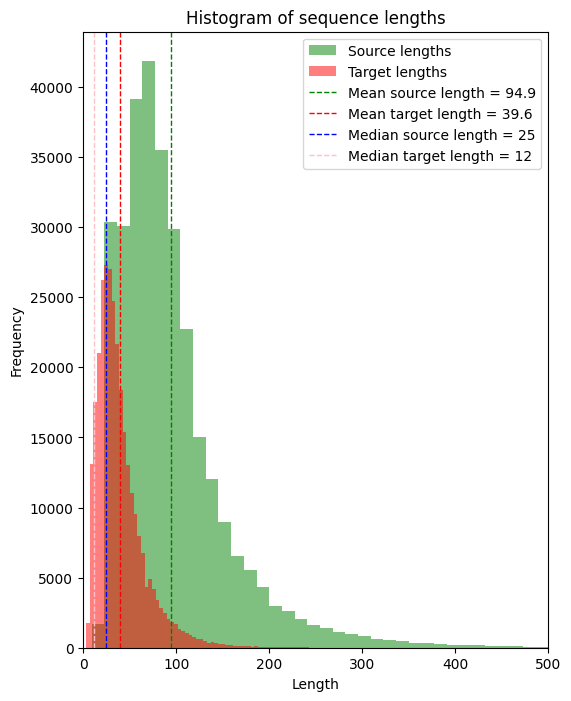

In [6]:
plt.figure(figsize=(6, 8))
plt.hist(src_lengths, bins=100, alpha=0.5, label='Source lengths', color='green')
plt.hist(dst_lengths, bins=100, alpha=0.5, label='Target lengths', color='red')
plt.axvline(np.mean(src_lengths), color='green', linestyle='dashed', linewidth=1, label=f'Mean source length = {np.mean(src_lengths):.1f}')
plt.axvline(np.mean(dst_lengths), color='red', linestyle='dashed', linewidth=1, label=f'Mean target length = {np.mean(dst_lengths):.1f}')
plt.axvline(scipy.stats.mode(src_lengths).mode, color='blue', linestyle='dashed', linewidth=1, label=f'Median source length = {scipy.stats.mode(src_lengths).mode}')
plt.axvline(scipy.stats.mode(dst_lengths).mode, color='pink', linestyle='dashed', linewidth=1, label=f'Median target length = {scipy.stats.mode(dst_lengths).mode}')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.title('Histogram of sequence lengths')
plt.xlim(0, 500)
plt.legend()
plt.show()

In [7]:
def normalize_text(s: str):
    return ' '.join(unicodedata.normalize('NFC', s).lower().split())

PAD, SOS, EOS = 0, 1, 2
BYTE_OFFSET = 3
VOCAB_SIZE = 256 + BYTE_OFFSET
MAX_SRC_LEN = 512
MAX_TGT_LEN = 256

class ByteTokenizer:
    def encode(self, text : str) -> List[int]:
        text = normalize_text(text)
        b = text.encode()
        ids = [SOS] + [BYTE_OFFSET + x for x in b] + [EOS]
        return ids
    

    def decode(self, ids : List[int]) -> str:
        buff = []
        for b in ids:
            if b == EOS:
                break
            if b in (PAD, SOS) or b < BYTE_OFFSET or b >= VOCAB_SIZE:
                continue
            buff.append(b - BYTE_OFFSET)
        return bytes(buff).decode(errors='replace')
    
    def batch_pad(self, sequences : List[List[int]]):
        max_len = max([len(s) for s in sequences])
        padded, masks = [], []
        for s in sequences:
            padded.append(s + [PAD] * (max_len - len(s)))
            masks.append([1] * len(s) + [0] * (max_len - len(s)))
        return padded, masks
     
    def truncate_with_eos(self, ids : List[int], max_len : int) -> List[int]:
        if len(ids) <= max_len:
            return ids
        ids = ids[:max_len]
        ids[-1] = EOS
        return ids

    def collate_batch(self, batch : List[Tuple[str, Optional[str]]], max_src_len=MAX_SRC_LEN, max_tgt_len=MAX_TGT_LEN):
        src_seqs = [self.truncate_with_eos(self.encode(src), max_src_len) for src, _ in batch]
        has_dst = all(d is not None for (_, d) in batch)
        
        src_ids, src_mask = self.batch_pad(src_seqs)

        out = {
            'src_ids' : torch.tensor(src_ids, dtype=torch.long),
            'src_pad_mask' : torch.tensor(src_mask, dtype=torch.bool)
        }

        if has_dst:
            tgt_seqs = [self.truncate_with_eos(self.encode(tgt), max_tgt_len) for _, tgt in batch]
            tgt_ids, tgt_mask = self.batch_pad(tgt_seqs)

            tgt_ids = torch.tensor(tgt_ids, dtype=torch.long)
            tgt_mask = torch.tensor(tgt_mask, dtype=torch.bool)
            decoder_input_ids = tgt_ids[:, :-1]
            decoder_pad_mask  = tgt_mask[:, :-1]

            labels = tgt_ids[:, 1:].clone()
            labels[labels == PAD] = -100

            out.update({
                'decoder_input_ids' : decoder_input_ids,
                'decoder_pad_mask' : decoder_pad_mask,
                'labels' : labels
            })

        return out
        

In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 4096):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe)  # (L, D)

    def forward(self, x):  # x: (L, B, D)
        L = x.size(0)
        return x + self.pe[:L].unsqueeze(1)

class TorchTransformerSeq2Seq(nn.Module):
    def __init__(
        self,
        vocab_size: int = VOCAB_SIZE,
        d_model: int = 512,
        nhead: int = 8,
        num_encoder_layers: int = 6,
        num_decoder_layers: int = 6,
        dim_feedforward: int = 2048,
        dropout: float = 0.1,
        pad_id: int = PAD,
        sos_id: int = SOS,
        eos_id: int = EOS,
        max_len: int = 4096,
        tie_embeddings: bool = True,
    ):
        super().__init__()
        self.pad_id, self.sos_id, self.eos_id = pad_id, sos_id, eos_id

        self.emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos = PositionalEncoding(d_model, max_len=max_len)
        self.drop = nn.Dropout(dropout)

        self.tf = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=False,  # PyTorch Transformer ожидает (L, B, D)
        )

        self.proj = nn.Linear(d_model, vocab_size, bias=False)
        if tie_embeddings:
            self.proj.weight = self.emb.weight  # weight tying

    def _key_padding(self, pad_mask_B_L):
        # PyTorch ждёт True = "маскировать" (т.е. там PAD)
        if pad_mask_B_L.dtype != torch.bool:
            pad_mask_B_L = pad_mask_B_L.bool()
        return ~pad_mask_B_L  # сейчас 1=не PAD -> инвертируем

    def _causal_mask(self, L, device):
        # (L, L), -inf выше диагонали (PyTorch>1.12 принимает float mask)
        m = torch.full((L, L), float("-inf"), device=device)
        return torch.triu(m, diagonal=1)

    def forward(self, src_ids, src_pad_mask, decoder_input_ids, decoder_pad_mask):
        """
        src_ids:           (B, Ls)
        src_pad_mask:      (B, Ls) 1=не PAD
        decoder_input_ids: (B, Lt)
        decoder_pad_mask:  (B, Lt) 1=не PAD
        -> logits:         (B, Lt, V)
        """
        B, Ls = src_ids.size()
        Lt = decoder_input_ids.size(1)
        device = src_ids.device

        # Embeddings + pos (-> (L,B,D) для nn.Transformer)
        src = self.emb(src_ids) * math.sqrt(self.emb.embedding_dim)
        src = self.drop(src).transpose(0, 1)           # (Ls, B, D)
        src = self.pos(src)

        tgt = self.emb(decoder_input_ids) * math.sqrt(self.emb.embedding_dim)
        tgt = self.drop(tgt).transpose(0, 1)           # (Lt, B, D)
        tgt = self.pos(tgt)

        # Masks
        src_key_padding = self._key_padding(src_pad_mask)          # True там, где PAD
        tgt_key_padding = self._key_padding(decoder_pad_mask)
        tgt_attn_mask  = self._causal_mask(Lt, device)

        out = self.tf(
            src=src,
            tgt=tgt,
            src_key_padding_mask=src_key_padding,
            tgt_key_padding_mask=tgt_key_padding,
            memory_key_padding_mask=src_key_padding,
            tgt_mask=tgt_attn_mask,
        )  # (Lt, B, D)

        logits = self.proj(out.transpose(0, 1))  # (B, Lt, V)
        return logits

    @torch.no_grad()
    def generate(self, src_ids, src_pad_mask, max_new_tokens=256, stop_at_eos=True):
        """
        Гриди-декодер поверх уже готовой архитектуры.
        Возвращает полную последовательность, начиная с SOS.
        """
        device = src_ids.device
        B, Ls = src_ids.size()

        # Этап encode
        src = self.emb(src_ids) * math.sqrt(self.emb.embedding_dim)
        src = self.drop(src).transpose(0, 1)
        src = self.pos(src)

        src_key_padding = self._key_padding(src_pad_mask)
        memory = self.tf.encoder(src, src_key_padding_mask=src_key_padding)  # (Ls, B, D)

        # Декодируем пошагово
        ys = torch.full((B, 1), self.sos_id, dtype=torch.long, device=device)
        for _ in range(max_new_tokens):
            tgt = self.emb(ys) * math.sqrt(self.emb.embedding_dim)
            tgt = self.drop(tgt).transpose(0, 1)
            tgt = self.pos(tgt)

            tgt_mask = self._causal_mask(tgt.size(0), device)
            tgt_key_padding = self._key_padding((ys != self.pad_id).long())

            dec_out = self.tf.decoder(
                tgt,
                memory,
                tgt_mask=tgt_mask,
                tgt_key_padding_mask=tgt_key_padding,
                memory_key_padding_mask=src_key_padding,
            )  # (Lt, B, D)

            next_logits = self.proj(dec_out[-1])   # (B, V)
            next_tok = next_logits.argmax(-1, keepdim=True)  # (B,1)

            ys = torch.cat([ys, next_tok], dim=1)
            if stop_at_eos and torch.all(next_tok.squeeze(1) == self.eos_id):
                break
        return ys


In [ ]:
# train_mps_zetan.py
import os, math, random
from typing import List
from contextlib import nullcontext

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.amp import autocast
from tqdm import tqdm

# ---- возьми это из своих модулей ----
# from zetan_dataset import ZetanDataset
# from zetan_tokenizer import ByteTokenizer, PAD, SOS, EOS, VOCAB_SIZE
# from torch_transformer_seq2seq import TorchTransformerSeq2Seq

def set_seed(seed: int = 42):
    random.seed(seed)
    torch.manual_seed(seed)
    try:
        torch.mps.manual_seed(seed)  # на всякий, если доступно
    except Exception:
        pass

def corpus_bleu(preds: List[str], refs: List[str]) -> float:
    try:
        import sacrebleu
        return sacrebleu.corpus_bleu(preds, [refs]).score
    except Exception:
        # простой fallback
        from collections import Counter
        def ngrams(tokens, n): return [" ".join(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
        max_order, smooth = 4, 1e-9
        matches, possibles = [0]*max_order, [0]*max_order
        ref_len = hyp_len = 0
        for h, r in zip(preds, refs):
            ht, rt = h.split(), r.split()
            hyp_len += len(ht); ref_len += len(rt)
            ref_ngr, hyp_ngr = Counter(), Counter()
            for n in range(1, max_order+1):
                ref_ngr.update(ngrams(rt, n)); hyp_ngr.update(ngrams(ht, n))
            overlap = hyp_ngr & ref_ngr
            for n in range(1, max_order+1):
                matches[n-1]   += sum(v for k,v in overlap.items() if len(k.split())==n)
                possibles[n-1] += max(len(ht)-n+1, 0)
        precs = [(matches[i]+smooth)/(possibles[i]+smooth) if possibles[i]>0 else 0.0 for i in range(max_order)]
        if hyp_len==0 or ref_len==0: return 0.0
        ratio = hyp_len / ref_len
        bp = 1.0 if ratio>1.0 else math.exp(1 - 1/ratio)
        score = bp * math.exp(sum((1/max_order)*math.log(p if p>0 else smooth) for p in precs))
        return 100.0*score

@torch.no_grad()
def evaluate_bleu(model, dataset, tokenizer, device, max_new_tokens=256, batch_size=64) -> float:
    model.eval()
    preds, refs = [], []
    for i in range(0, len(dataset), batch_size):
        pairs = [dataset[j] for j in range(i, min(i+batch_size, len(dataset)))]
        batch = tokenizer.collate_batch(pairs, max_tgt_len=max_new_tokens)
        src_ids = batch["src_ids"].to(device)
        src_pad = batch["src_pad_mask"].to(device)
        out = model.generate(src_ids, src_pad, max_new_tokens=max_new_tokens, stop_at_eos=True)
        preds.extend([tokenizer.decode(seq.tolist()) for seq in out])
        refs.extend([dst if dst is not None else "" for _, dst in pairs])
    return corpus_bleu(preds, refs)

def train_loop(
    data_dir: str,
    out_dir: str = "chk/torch_tf_zetan_mps",
    epochs: int = 10,
    batch_size: int = 32,
    lr: float = 2e-4,
    weight_decay: float = 0.01,
    label_smoothing: float = 0.1,
    grad_clip: float = 1.0,
    warmup_steps: int = 2000,
    eval_every: int = 1,
    seed: int = 42,
    max_src_len: int = 256,
    max_tgt_len: int = 256,
):
    os.makedirs(out_dir, exist_ok=True)
    set_seed(seed)

    # --- девайс и AMP для MPS ---
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        amp_enabled = True   # MPS autocast fp16 ускоряет
        amp_ctx = lambda: autocast(device_type="mps", dtype=torch.float16, enabled=amp_enabled)
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        amp_enabled = True
        amp_ctx = lambda: autocast(device_type="cuda", dtype=torch.float16, enabled=amp_enabled)
    else:
        device = torch.device("cpu")
        amp_enabled = False
        amp_ctx = lambda: nullcontext()

    # --- data ---
    tokenizer = ByteTokenizer()
    train_ds = ZetanDataset(data_dir, "train")
    val_ds   = ZetanDataset(data_dir, "val")

    def collate_fn(batch, tok=tokenizer, msl=max_src_len, mtl=max_tgt_len):
        return tok.collate_batch(batch, max_src_len=msl, max_tgt_len=mtl)

    # На macOS/MPS экономим на форк/пиклинге и pin_memory
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=0, pin_memory=False, collate_fn=collate_fn)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=0, pin_memory=False, collate_fn=collate_fn)

    # --- model ---
    model = TorchTransformerSeq2Seq(
        vocab_size=VOCAB_SIZE,
        d_model=512, nhead=8, num_encoder_layers=6, num_decoder_layers=6,
        dim_feedforward=2048, dropout=0.1,
        pad_id=PAD, sos_id=SOS, eos_id=EOS,
    ).to(device)

    # --- optim/sched/loss ---
    criterion = nn.CrossEntropyLoss(ignore_index=-100, label_smoothing=label_smoothing)
    optimizer = optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.98), weight_decay=weight_decay)

    total_steps = epochs * max(1, len(train_loader))
    def lr_lambda(step):
        if step < warmup_steps:
            return max(1e-8, step / max(1, warmup_steps))
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * progress))
    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

    best_bleu = -1.0
    best_path = os.path.join(out_dir, "best.pt")

    global_step = 0
    for epoch in range(1, epochs+1):
        model.train()
        running_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False)
        for batch in pbar:
            src_ids = batch["src_ids"].to(device)
            src_pad = batch["src_pad_mask"].to(device)
            dec_inp = batch["decoder_input_ids"].to(device)
            dec_pad = batch["decoder_pad_mask"].to(device)
            labels  = batch["labels"].to(device)

            optimizer.zero_grad(set_to_none=True)
            with amp_ctx():
                logits = model(src_ids, src_pad, dec_inp, dec_pad)   # (B, Lt, V)
                loss = criterion(logits.reshape(-1, logits.size(-1)), labels.reshape(-1))

            # На MPS/CPU GradScaler не нужен — обычный backward
            loss.backward()
            if grad_clip and grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            scheduler.step()

            running_loss += loss.item()
            global_step += 1
            pbar.set_postfix(loss=f"{loss.item():.3f}", lr=f"{scheduler.get_last_lr()[0]:.2e}")

        train_loss = running_loss / max(1, len(train_loader))

        # --- evaluation ---
        model.eval()
        with torch.no_grad():
            losses = []
            for batch in val_loader:
                src_ids = batch["src_ids"].to(device)
                src_pad = batch["src_pad_mask"].to(device)
                dec_inp = batch["decoder_input_ids"].to(device)
                dec_pad = batch["decoder_pad_mask"].to(device)
                labels  = batch["labels"].to(device)
                with amp_ctx():
                    logits = model(src_ids, src_pad, dec_inp, dec_pad)
                    l = criterion(logits.reshape(-1, logits.size(-1)), labels.reshape(-1)).item()
                losses.append(l)
            val_loss = sum(losses) / max(1, len(losses))

        bleu = None
        if epoch % eval_every == 0:
            bleu = evaluate_bleu(model, val_ds, tokenizer, device=device, max_new_tokens=max_tgt_len, batch_size=64)

        msg = f"[Epoch {epoch}] train_loss={train_loss:.3f} val_loss={val_loss:.3f}"
        if bleu is not None:
            msg += f" BLEU={bleu:.2f}"
        print(msg)

        if bleu is not None and bleu > best_bleu:
            best_bleu = bleu
            torch.save({
                "model_state": model.state_dict(),
                "config": {
                    "vocab_size": VOCAB_SIZE, "pad_id": PAD, "sos_id": SOS, "eos_id": EOS,
                    "d_model": 512, "nhead": 8, "num_encoder_layers": 6, "num_decoder_layers": 6,
                    "dim_feedforward": 2048, "dropout": 0.1
                }
            }, best_path)
            print(f"✓ Saved best model to: {best_path} (BLEU={best_bleu:.2f})")

    print("Training finished.")
    if os.path.exists(best_path):
        print(f"Best BLEU: {best_bleu:.2f} | checkpoint: {best_path}")
    else:
        print("No best checkpoint was saved (check eval_every / BLEU computation).")


train_loop('data')

/Users/mishasmacbook/Desktop/HSE/datas/.venv/lib/python3.13/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
Epoch 1/10:   0%|          | 0/9375 [00:00<?, ?it/s]/Users/mishasmacbook/Desktop/HSE/datas/.venv/lib/python3.13/site-packages/torch/nn/functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
                                                                                          